# ML Data Preparation and Preprocessing — Aadya

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/KrishiNayan")
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
CLEAN_DATA_DIR = PROJECT_DIR / "data" / "processed"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)

In [ ]:
!git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git /content/PlantVillage-Dataset



In [ ]:
SOURCE_DIR = Path("/content/PlantVillage-Dataset/raw/color")

print("Dataset exists:", SOURCE_DIR.exists())


In [ ]:
CLASSES = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot"
]

for class_name in CLASSES:
    class_path = SOURCE_DIR / class_name
    print(
        class_name,
        "✅ Found" if class_path.exists() else "❌ Missing"
    )

##Validate Images and Count Classes

In [ ]:
import pandas as pd
from PIL import Image, UnidentifiedImageError

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

valid_images = []
invalid_images = []

for class_name in CLASSES:
    class_folder = SOURCE_DIR / class_name

    for image_path in class_folder.iterdir():
        if image_path.suffix.lower() not in VALID_EXTENSIONS:
            continue

        try:
            # Check whether the image is damaged
            with Image.open(image_path) as image:
                image.verify()

            # Reopen it to read its properties
            with Image.open(image_path) as image:
                width, height = image.size
                mode = image.mode

            valid_images.append({
                "filepath": str(image_path),
                "filename": image_path.name,
                "label": class_name,
                "width": width,
                "height": height,
                "color_mode": mode
            })

        except (UnidentifiedImageError, OSError, ValueError) as error:
            invalid_images.append({
                "filepath": str(image_path),
                "error": str(error)
            })

metadata_df = pd.DataFrame(valid_images)
invalid_df = pd.DataFrame(invalid_images)

print("Total valid images:", len(metadata_df))
print("Total invalid images:", len(invalid_df))

In [ ]:
class_counts = (
    metadata_df["label"]
    .value_counts()
    .reindex(CLASSES)
    .rename_axis("Class")
    .reset_index(name="Image Count")
)

display(class_counts)

In [ ]:
REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

class_counts.to_csv(
    REPORTS_DIR / "class_counts.csv",
    index=False
)

metadata_df.to_csv(
    REPORTS_DIR / "image_metadata.csv",
    index=False
)

invalid_df.to_csv(
    REPORTS_DIR / "invalid_images.csv",
    index=False
)

print("Reports saved in:", REPORTS_DIR)

##Create Train, Validation and Test Splits

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

# First split: 70% train and 30% temporary
train_df, temporary_df = train_test_split(
    metadata_df,
    test_size=0.30,
    stratify=metadata_df["label"],
    random_state=SEED
)

# Divide temporary data equally: 15% validation and 15% test
validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

print("Total images:", len(metadata_df))
print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Testing images:", len(test_df))

assert len(train_df) + len(validation_df) + len(test_df) == len(metadata_df)

In [ ]:
train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
validation_df["split"] = "validation"
test_df["split"] = "test"

split_df = pd.concat(
    [train_df, validation_df, test_df],
    ignore_index=True
)

In [ ]:
split_counts = pd.crosstab(
    split_df["label"],
    split_df["split"]
).reindex(CLASSES)

split_counts["total"] = split_counts.sum(axis=1)

display(split_counts)

In [ ]:
assert len(split_df) == 7223
assert set(split_df["label"].unique()) == set(CLASSES)
assert split_df["filepath"].duplicated().sum() == 0

print("✅ Stratified split completed successfully")

In [ ]:
split_df.to_csv(
    REPORTS_DIR / "dataset_split.csv",
    index=False
)

split_counts.to_csv(
    REPORTS_DIR / "split_counts.csv"
)

print("✅ Split reports saved in:", REPORTS_DIR)

##  Create Dataset Folders and Resize Images to 224x224

In [ ]:
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

OUTPUT_DIR = Path("/content/tomato_dataset_224")
IMAGE_SIZE = (224, 224)

# Create train/validation/test class folders
for split_name in ["train", "validation", "test"]:
    for class_name in CLASSES:
        folder = OUTPUT_DIR / split_name / class_name
        folder.mkdir(parents=True, exist_ok=True)

print("✅ Output folders created")

In [ ]:
processing_errors = []

for _, row in tqdm(
    split_df.iterrows(),
    total=len(split_df),
    desc="Resizing images"
):
    source_path = Path(row["filepath"])
    split_name = row["split"]
    class_name = row["label"]

    # Save everything consistently as JPG
    destination_name = source_path.stem + ".jpg"

    destination_path = (
        OUTPUT_DIR
        / split_name
        / class_name
        / destination_name
    )

    try:
        with Image.open(source_path) as image:
            image = image.convert("RGB")
            image = image.resize(
                IMAGE_SIZE,
                Image.Resampling.LANCZOS
            )

            image.save(
                destination_path,
                format="JPEG",
                quality=95
            )

    except Exception as error:
        processing_errors.append({
            "source": str(source_path),
            "error": str(error)
        })

print("Successfully processed:", len(split_df) - len(processing_errors))
print("Processing errors:", len(processing_errors))

In [ ]:
processed_records = []

for split_name in ["train", "validation", "test"]:
    for class_name in CLASSES:
        folder = OUTPUT_DIR / split_name / class_name

        for image_path in folder.glob("*.jpg"):
            with Image.open(image_path) as image:
                processed_records.append({
                    "split": split_name,
                    "label": class_name,
                    "filepath": str(image_path),
                    "width": image.width,
                    "height": image.height,
                    "mode": image.mode
                })

processed_df = pd.DataFrame(processed_records)

print("Processed images:", len(processed_df))
print("Correct width:", (processed_df["width"] == 224).all())
print("Correct height:", (processed_df["height"] == 224).all())
print("RGB images:", (processed_df["mode"] == "RGB").all())

In [ ]:
assert len(processed_df) == 7223
assert (processed_df["width"] == 224).all()
assert (processed_df["height"] == 224).all()
assert (processed_df["mode"] == "RGB").all()
assert set(processed_df["label"].unique()) == set(CLASSES)

print("✅ All 7,223 images were resized and verified successfully")

In [ ]:
processed_counts = pd.crosstab(
    processed_df["label"],
    processed_df["split"]
).reindex(CLASSES)

processed_counts["total"] = processed_counts.sum(axis=1)

display(processed_counts)

## Load Dataset and Add Training Augmentation

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "validation",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

In [ ]:
CLASS_NAMES = train_ds.class_names

class_mapping = {
    index: class_name
    for index, class_name in enumerate(CLASS_NAMES)
}

print("Class mapping:")
for number, class_name in class_mapping.items():
    print(number, "→", class_name)

In [ ]:
import json

with open(REPORTS_DIR / "class_mapping.json", "w") as file:
    json.dump(class_mapping, file, indent=4)

print("✅ Class mapping saved")

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        mode="horizontal",
        seed=SEED
    ),

    tf.keras.layers.RandomRotation(
        factor=0.08,
        fill_mode="reflect",
        seed=SEED
    ),

    tf.keras.layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="reflect",
        seed=SEED
    ),

    tf.keras.layers.RandomBrightness(
        factor=0.15,
        value_range=(0, 255),
        seed=SEED
    )
], name="data_augmentation")

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))
sample_image = images[0]

plt.figure(figsize=(10, 10))

for index in range(9):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    axis = plt.subplot(3, 3, index + 1)
    plt.imshow(
        tf.cast(augmented_image[0], tf.uint8)
    )
    plt.axis("off")

plt.suptitle("Training Augmentation Preview")
plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("✅ TensorFlow datasets are ready for training")

In [ ]:
!du -sh /content/tomato_dataset_224

In [ ]:
import shutil
from pathlib import Path

LOCAL_ZIP = "/content/tomato_dataset_clean"

shutil.make_archive(
    LOCAL_ZIP,
    "zip",
    root_dir=OUTPUT_DIR
)

print("✅ ZIP created:", LOCAL_ZIP + ".zip")

In [ ]:
DRIVE_ZIP = PROJECT_DIR / "data" / "tomato_dataset_clean.zip"

shutil.copy2(
    LOCAL_ZIP + ".zip",
    DRIVE_ZIP
)

print("✅ Dataset saved to Drive:")
print(DRIVE_ZIP)

In [ ]:
class_counts.to_csv(
    REPORTS_DIR / "class_counts.csv",
    index=False
)

processed_counts.to_csv(
    REPORTS_DIR / "final_split_counts.csv"
)

processed_df.to_csv(
    REPORTS_DIR / "processed_image_metadata.csv",
    index=False
)

print("✅ All CSV reports saved")

In [ ]:
summary = f"""
KrishiNayan Tomato Dataset Summary
==================================

Total images: {len(processed_df)}
Number of classes: {len(CLASSES)}
Image size: 224 x 224
Colour mode: RGB

Training images: {len(train_df)}
Validation images: {len(validation_df)}
Testing images: {len(test_df)}

Classes:
{chr(10).join(CLASSES)}

Augmentation applied during training only:
- Horizontal flip
- Rotation
- Zoom
- Brightness adjustment

Random seed: {SEED}
"""

SUMMARY_PATH = REPORTS_DIR / "dataset_summary.txt"

with open(SUMMARY_PATH, "w") as file:
    file.write(summary)

print(summary)
print("✅ Summary saved:", SUMMARY_PATH)

In [ ]:
required_files = [
    DRIVE_ZIP,
    REPORTS_DIR / "class_counts.csv",
    REPORTS_DIR / "final_split_counts.csv",
    REPORTS_DIR / "processed_image_metadata.csv",
    REPORTS_DIR / "dataset_split.csv",
    REPORTS_DIR / "class_mapping.json",
    REPORTS_DIR / "dataset_summary.txt"
]

for file_path in required_files:
    status = "✅" if file_path.exists() else "❌"
    print(status, file_path.name)

# Final Preprocessing Result

- Total images: 7,223
- Classes: 5
- Training images: 5,056
- Validation images: 1,083
- Testing images: 1,084
- Image size: 224 × 224
- Colour mode: RGB
- Invalid images: 0
- Split method: Stratified 70/15/15
- Augmentation: Horizontal flip, rotation, zoom and brightness
- Augmentation is applied only during training.
- Dataset and reports have been saved successfully.

## Create Final Dataset With Readable Folder Names

In [ ]:
FOLDER_NAME_MAPPING = {
    "Tomato___healthy": "Healthy",
    "Tomato___Early_blight": "Early Blight",
    "Tomato___Late_blight": "Late Blight",
    "Tomato___Leaf_Mold": "Leaf Mold",
    "Tomato___Septoria_leaf_spot": "Septoria Leaf Spot"
}

In [ ]:
import shutil
from pathlib import Path

SOURCE_PROCESSED_DIR = Path("/content/tomato_dataset_224")
FINAL_DATASET_DIR = Path("/content/KrishiNayan_dataset")

# Rebuild only this generated folder if the cell is rerun
if FINAL_DATASET_DIR.exists():
    shutil.rmtree(FINAL_DATASET_DIR)

for split_name in ["train", "validation", "test"]:
    for old_name, new_name in FOLDER_NAME_MAPPING.items():

        source_folder = (
            SOURCE_PROCESSED_DIR
            / split_name
            / old_name
        )

        destination_folder = (
            FINAL_DATASET_DIR
            / split_name
            / new_name
        )

        shutil.copytree(
            source_folder,
            destination_folder
        )

print("✅ KrishiNayan dataset structure created")

✅ KrishiNayan dataset structure created


In [ ]:
final_rows = []

for split_name in ["train", "validation", "test"]:
    for class_name in FOLDER_NAME_MAPPING.values():
        folder = FINAL_DATASET_DIR / split_name / class_name
        image_count = len(list(folder.glob("*.jpg")))

        final_rows.append({
            "class": class_name,
            "split": split_name,
            "image_count": image_count
        })

final_structure_df = pd.DataFrame(final_rows)

final_structure_counts = pd.pivot_table(
    final_structure_df,
    index="class",
    columns="split",
    values="image_count",
    aggfunc="sum"
)

final_structure_counts["total"] = (
    final_structure_counts.sum(axis=1)
)

display(final_structure_counts)

assert final_structure_counts["total"].sum() == 7223
assert final_structure_counts["train"].sum() == 5056
assert final_structure_counts["validation"].sum() == 1083
assert final_structure_counts["test"].sum() == 1084

print("✅ New dataset contains all 7,223 images")

split,test,train,validation,total
class,,,,
Early Blight,150,700,150,1000
Healthy,238,1114,239,1591
Late Blight,287,1336,286,1909
Leaf Mold,143,666,143,952
Septoria Leaf Spot,266,1240,265,1771


✅ New dataset contains all 7,223 images


In [ ]:
import json

FINAL_CLASS_NAMES = sorted(
    FOLDER_NAME_MAPPING.values()
)

final_class_mapping = {
    index: class_name
    for index, class_name in enumerate(FINAL_CLASS_NAMES)
}

print(final_class_mapping)

with open(
    REPORTS_DIR / "final_class_mapping.json",
    "w"
) as file:
    json.dump(final_class_mapping, file, indent=4)

print("✅ Updated class mapping saved")

{0: 'Early Blight', 1: 'Healthy', 2: 'Late Blight', 3: 'Leaf Mold', 4: 'Septoria Leaf Spot'}
✅ Updated class mapping saved


In [ ]:
FINAL_ZIP_BASE = "/content/KrishiNayan_dataset"

shutil.make_archive(
    FINAL_ZIP_BASE,
    "zip",
    root_dir=FINAL_DATASET_DIR
)

print("✅ ZIP created")

✅ ZIP created


In [ ]:
DRIVE_FINAL_ZIP = (
    PROJECT_DIR
    / "data"
    / "KrishiNayan_dataset.zip"
)

shutil.copy2(
    FINAL_ZIP_BASE + ".zip",
    DRIVE_FINAL_ZIP
)

print("✅ Final dataset saved at:")
print(DRIVE_FINAL_ZIP)

✅ Final dataset saved at:
/content/drive/MyDrive/KrishiNayan/data/KrishiNayan_dataset.zip


# 2. Model Training

In [ ]:
!nvidia-smi

Tue Aug  4 04:54:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Import Libraries

In [ ]:
import os
import json
import zipfile
import random

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Configuration

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

INITIAL_EPOCHS = 15
INITIAL_LEARNING_RATE = 1e-3

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 32
Number of classes: 5


#Find uploaded zip file

In [ ]:
from pathlib import Path

zip_files = list(
    Path("/content").glob("*.zip")
)

if len(zip_files) == 0:
    print("No ZIP file found in /content.")
    print("Upload the ZIP using the Files panel.")

elif len(zip_files) == 1:
    ZIP_PATH = zip_files[0]

    print("ZIP found:")
    print(ZIP_PATH)

else:
    print("Multiple ZIP files found:")

    for index, zip_file in enumerate(zip_files):
        print(index, "->", zip_file)

    # Change the index if needed
    ZIP_PATH = zip_files[0]

    print("\nSelected:")
    print(ZIP_PATH)

ZIP found:
/content/KrishiNayan_dataset.zip


In [ ]:
import zipfile
from pathlib import Path

EXTRACT_DIR = Path(
    "/content/KrishiNayan_dataset"
)

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zip_file:
    zip_file.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")
print("Location:", EXTRACT_DIR)

Dataset extracted successfully.
Location: /content/KrishiNayan_dataset


In [ ]:
ZIP_PATH = zip_files[0]

print("Selected ZIP:", ZIP_PATH)

Selected ZIP: /content/KrishiNayan_dataset.zip


#Extract Dataset

In [ ]:
EXTRACT_DIR = Path(
    "/content/KrishiNayan_dataset"
)

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")
print("Extraction location:", EXTRACT_DIR)

Dataset extracted successfully.
Extraction location: /content/KrishiNayan_dataset


#Dataset Root

In [ ]:
def find_dataset_root(search_directory):
    possible_roots = [
        search_directory,
        *[
            path
            for path in search_directory.rglob("*")
            if path.is_dir()
        ]
    ]

    for candidate in possible_roots:
        train_exists = (
            candidate / "train"
        ).is_dir()

        validation_exists = any(
            (candidate / name).is_dir()
            for name in [
                "validation",
                "valid",
                "val"
            ]
        )

        test_exists = (
            candidate / "test"
        ).is_dir()

        if (
            train_exists
            and validation_exists
            and test_exists
        ):
            return candidate

    return None


DATASET_DIR = find_dataset_root(EXTRACT_DIR)

if DATASET_DIR is None:
    print(
        "Could not find train, validation "
        "and test folders."
    )

else:
    print("Dataset root:", DATASET_DIR)

Dataset root: /content/KrishiNayan_dataset


#Define split paths

In [ ]:
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

if (DATASET_DIR / "validation").is_dir():
    VALIDATION_DIR = DATASET_DIR / "validation"

elif (DATASET_DIR / "valid").is_dir():
    VALIDATION_DIR = DATASET_DIR / "valid"

elif (DATASET_DIR / "val").is_dir():
    VALIDATION_DIR = DATASET_DIR / "val"

else:
    raise FileNotFoundError(
        "Validation folder not found."
    )

print("Train:", TRAIN_DIR)
print("Validation:", VALIDATION_DIR)
print("Test:", TEST_DIR)

Train: /content/KrishiNayan_dataset/train
Validation: /content/KrishiNayan_dataset/validation
Test: /content/KrishiNayan_dataset/test


#Exact folder class name

In [ ]:
CLASS_FOLDER_NAMES = sorted(
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
    and not folder.name.startswith(".")
)

print("Class folders found:")

for index, class_name in enumerate(
    CLASS_FOLDER_NAMES
):
    print(index, "->", class_name)

assert len(CLASS_FOLDER_NAMES) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, "
    f"but found {len(CLASS_FOLDER_NAMES)}."
)

Class folders found:
0 -> Early Blight
1 -> Healthy
2 -> Late Blight
3 -> Leaf Mold
4 -> Septoria Leaf Spot


#Display names

In [ ]:
from pathlib import Path

EXTRACT_DIR = Path(
    "/content/KrishiNayan_dataset"
)

NUM_CLASSES = 5


# Find the folder containing train/validation/test
def find_dataset_root(search_directory):
    directories = [
        search_directory,
        *[
            path
            for path in search_directory.rglob("*")
            if path.is_dir()
        ]
    ]

    for candidate in directories:
        train_exists = (
            candidate / "train"
        ).is_dir()

        validation_exists = any(
            (candidate / name).is_dir()
            for name in [
                "validation",
                "valid",
                "val"
            ]
        )

        test_exists = (
            candidate / "test"
        ).is_dir()

        if (
            train_exists
            and validation_exists
            and test_exists
        ):
            return candidate

    return None


DATASET_DIR = find_dataset_root(
    EXTRACT_DIR
)

if DATASET_DIR is None:
    raise FileNotFoundError(
        "Could not find train, validation "
        "and test folders inside the "
        "extracted dataset."
    )


# Define split paths
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

if (DATASET_DIR / "validation").is_dir():
    VALIDATION_DIR = (
        DATASET_DIR / "validation"
    )

elif (DATASET_DIR / "valid").is_dir():
    VALIDATION_DIR = DATASET_DIR / "valid"

elif (DATASET_DIR / "val").is_dir():
    VALIDATION_DIR = DATASET_DIR / "val"

else:
    raise FileNotFoundError(
        "Validation folder not found."
    )


# Detect class folders
CLASS_FOLDER_NAMES = sorted(
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
    and not folder.name.startswith(".")
)


# Create readable names
def create_display_name(folder_name):
    name = folder_name.replace(
        "Tomato___",
        ""
    )

    name = name.replace("_", " ")

    return name.title()


DISPLAY_CLASS_NAMES = [
    create_display_name(class_name)
    for class_name in CLASS_FOLDER_NAMES
]


# Display results
print("Dataset root:", DATASET_DIR)
print("Train folder:", TRAIN_DIR)
print("Validation folder:", VALIDATION_DIR)
print("Test folder:", TEST_DIR)

print("\nClasses found:")

for index, (
    folder_name,
    display_name
) in enumerate(
    zip(
        CLASS_FOLDER_NAMES,
        DISPLAY_CLASS_NAMES
    )
):
    print(
        f"{index}: "
        f"{folder_name} -> {display_name}"
    )

print(
    "\nNumber of classes:",
    len(CLASS_FOLDER_NAMES)
)

assert len(CLASS_FOLDER_NAMES) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, "
    f"but found {len(CLASS_FOLDER_NAMES)}."
)

Dataset root: /content/KrishiNayan_dataset
Train folder: /content/KrishiNayan_dataset/train
Validation folder: /content/KrishiNayan_dataset/validation
Test folder: /content/KrishiNayan_dataset/test

Classes found:
0: Early Blight -> Early Blight
1: Healthy -> Healthy
2: Late Blight -> Late Blight
3: Leaf Mold -> Leaf Mold
4: Septoria Leaf Spot -> Septoria Leaf Spot

Number of classes: 5


In [ ]:
def create_display_name(folder_name):
    display_name = folder_name

    display_name = display_name.replace(
        "Tomato___",
        ""
    )

    display_name = display_name.replace(
        "_",
        " "
    )

    return display_name.title()


DISPLAY_CLASS_NAMES = [
    create_display_name(class_name)
    for class_name in CLASS_FOLDER_NAMES
]

print("Model label mapping:")

for index, (
    folder_name,
    display_name
) in enumerate(
    zip(
        CLASS_FOLDER_NAMES,
        DISPLAY_CLASS_NAMES
    )
):
    print(
        f"{index}: "
        f"{folder_name} -> {display_name}"
    )

Model label mapping:
0: Early Blight -> Early Blight
1: Healthy -> Healthy
2: Late Blight -> Late Blight
3: Leaf Mold -> Leaf Mold
4: Septoria Leaf Spot -> Septoria Leaf Spot


#Validate all three splits

In [ ]:
def get_class_folders(split_directory):
    return sorted(
        folder.name
        for folder in split_directory.iterdir()
        if folder.is_dir()
        and not folder.name.startswith(".")
    )


train_classes = get_class_folders(TRAIN_DIR)
validation_classes = get_class_folders(
    VALIDATION_DIR
)
test_classes = get_class_folders(TEST_DIR)

assert train_classes == CLASS_FOLDER_NAMES, (
    "Unexpected train class folders."
)

assert validation_classes == CLASS_FOLDER_NAMES, (
    "Validation classes do not match "
    "training classes."
)

assert test_classes == CLASS_FOLDER_NAMES, (
    "Test classes do not match "
    "training classes."
)

print("All split folders are consistent.")

All split folders are consistent.


#Count images

In [ ]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

print("Supported image extensions:", IMAGE_EXTENSIONS)

Supported image extensions: {'.jpeg', '.png', '.jpg', '.bmp'}


In [ ]:
def count_images(directory):
    return sum(
        1
        for file in directory.rglob("*")
        if file.is_file()
        and file.suffix.lower()
        in IMAGE_EXTENSIONS
    )


for split_name, split_directory in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VALIDATION_DIR),
    ("TEST", TEST_DIR)
]:
    print(f"\n{split_name}")

    split_total = 0

    for class_name in CLASS_FOLDER_NAMES:
        class_directory = (
            split_directory / class_name
        )

        image_count = count_images(
            class_directory
        )

        split_total += image_count

        print(
            f"{class_name}: "
            f"{image_count}"
        )

    print("Total:", split_total)


TRAIN
Early Blight: 700
Healthy: 1114
Late Blight: 1336
Leaf Mold: 666
Septoria Leaf Spot: 1240
Total: 5056

VALIDATION
Early Blight: 150
Healthy: 239
Late Blight: 286
Leaf Mold: 143
Septoria Leaf Spot: 265
Total: 1083

TEST
Early Blight: 150
Healthy: 238
Late Blight: 287
Leaf Mold: 143
Septoria Leaf Spot: 266
Total: 1084


#Check damaged images

In [ ]:
from PIL import Image

damaged_images = []

for file in DATASET_DIR.rglob("*"):
    if (
        file.is_file()
        and file.suffix.lower()
        in IMAGE_EXTENSIONS
    ):
        try:
            with Image.open(file) as image:
                image.verify()

        except Exception as error:
            damaged_images.append(
                (str(file), str(error))
            )

print(
    "Damaged images:",
    len(damaged_images)
)

for file, error in damaged_images[:10]:
    print(file)
    print(error)

Damaged images: 0


#Load datasets

In [ ]:
train_dataset = (
    tf.keras.utils
    .image_dataset_from_directory(
        str(TRAIN_DIR),
        class_names=CLASS_FOLDER_NAMES,
        label_mode="int",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )
)

validation_dataset = (
    tf.keras.utils
    .image_dataset_from_directory(
        str(VALIDATION_DIR),
        class_names=CLASS_FOLDER_NAMES,
        label_mode="int",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
)

test_dataset = (
    tf.keras.utils
    .image_dataset_from_directory(
        str(TEST_DIR),
        class_names=CLASS_FOLDER_NAMES,
        label_mode="int",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
)

print("Datasets loaded successfully.")

Found 5056 files belonging to 5 classes.
Found 1083 files belonging to 5 classes.
Found 1084 files belonging to 5 classes.
Datasets loaded successfully.


#Improve dataset performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = (
    validation_dataset.prefetch(
        buffer_size=AUTOTUNE
    )
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipelines optimized.")

Dataset pipelines optimized.


#Display sample images

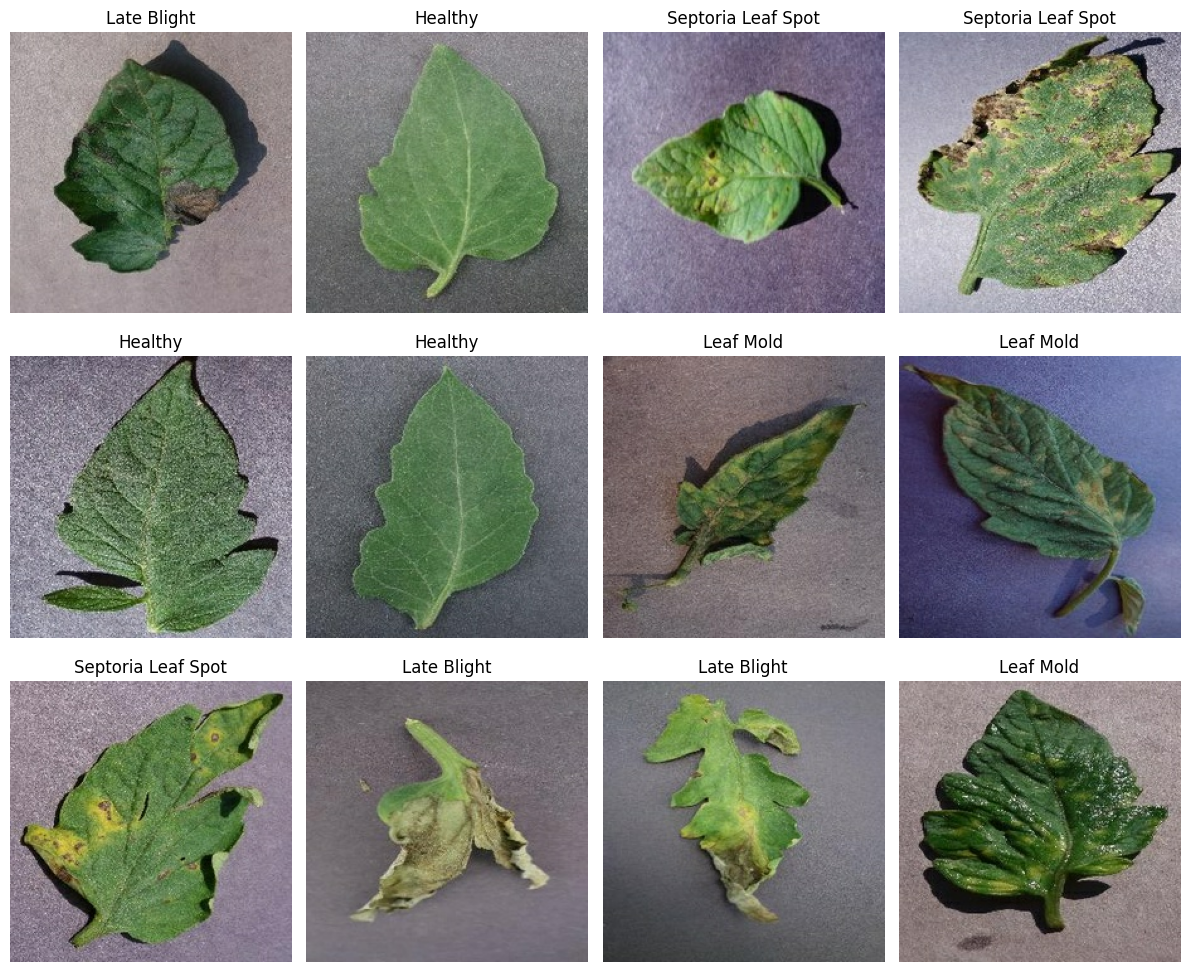

In [ ]:
plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):
    number_to_show = min(
        12,
        len(images)
    )

    for index in range(number_to_show):
        plt.subplot(3, 4, index + 1)

        plt.imshow(
            images[index]
            .numpy()
            .astype("uint8")
        )

        label_index = int(labels[index])

        plt.title(
            DISPLAY_CLASS_NAMES[
                label_index
            ]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

#Data augmetation

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),
        layers.RandomRotation(
            0.08
        ),
        layers.RandomZoom(
            0.10
        ),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
        layers.RandomContrast(
            0.10
        )
    ],
    name="data_augmentation"
)

print("Data augmentation ready.")

Data augmentation ready.


#Load efficientnetb0

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)

base_model.trainable = False

print("EfficientNetB0 loaded.")
print(
    "EfficientNet layers:",
    len(base_model.layers)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded.
EfficientNet layers: 238


#complete classifier

In [ ]:
inputs = keras.Input(
    shape=IMAGE_SIZE + (3,),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.25,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="disease_predictions"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="KrishiNayan_EfficientNetB0"
)

model.summary()

print("Output shape:", model.output_shape)

Model: "KrishiNayan_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease_predictions (Dense)     │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Output shape: (None, 5)


# Complie model

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=(
            INITIAL_LEARNING_RATE
        )
    ),
    loss=(
        keras.losses
        .SparseCategoricalCrossentropy()
    ),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


#Training callbacks

In [ ]:
OUTPUT_DIR = Path(
    "/content/KrishiNayan_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = (
    OUTPUT_DIR
    / "best_krishinayan_model.keras"
)

callbacks = [
    ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


#Train

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5964 - loss: 1.1092
Epoch 1: val_loss improved from None to 0.59121, saving model to /content/KrishiNayan_outputs/best_krishinayan_model.keras

Epoch 1: finished saving model to /content/KrishiNayan_outputs/best_krishinayan_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 43s 161ms/step - accuracy: 0.7199 - loss: 0.8500 - val_accuracy: 0.8024 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8476 - loss: 0.5072
Epoch 2: val_loss improved from 0.59121 to 0.45431, saving model to /content/KrishiNayan_outputs/best_krishinayan_model.keras

Epoch 2: finished saving model to /content/KrishiNayan_outputs/best_krishinayan_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.8598 - loss: 0.4742 - val_accuracy: 0.8412 - val_loss: 0.4543 - learning_rate: 0.0010
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8781 - loss: 0.4012
Epoch 3: val_los

#Plot accuracy and loss

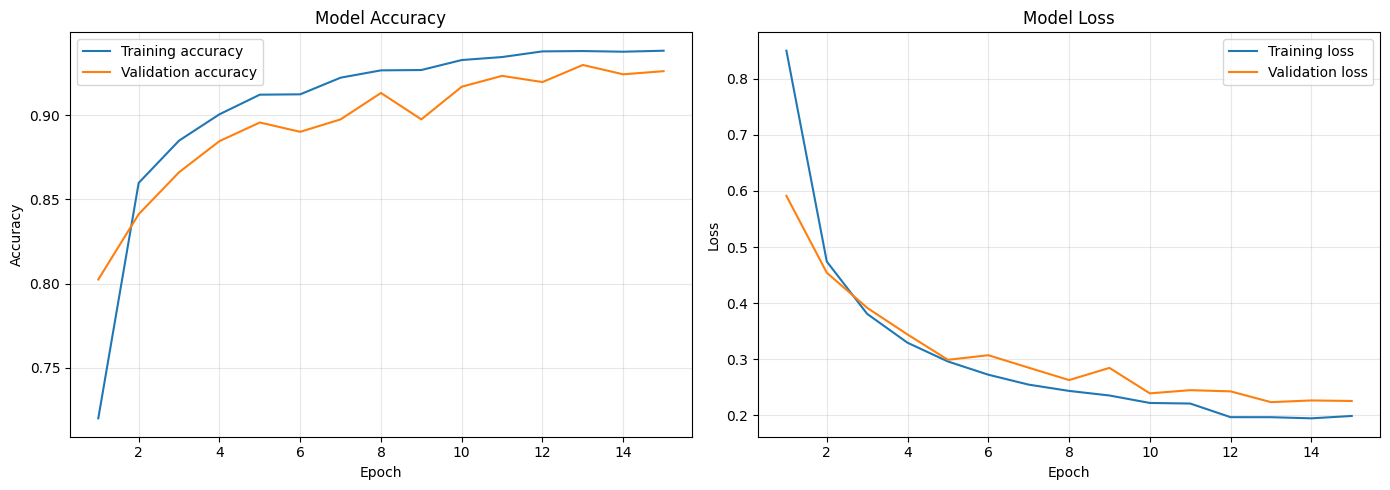

In [ ]:
training_accuracy = (
    history.history["accuracy"]
)

validation_accuracy = (
    history.history["val_accuracy"]
)

training_loss = (
    history.history["loss"]
)

validation_loss = (
    history.history["val_loss"]
)

epochs = range(
    1,
    len(training_accuracy) + 1
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs,
    training_accuracy,
    label="Training accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)

plt.plot(
    epochs,
    training_loss,
    label="Training loss"
)

plt.plot(
    epochs,
    validation_loss,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

PLOT_PATH = (
    OUTPUT_DIR
    / "training_curves.png"
)

plt.savefig(
    PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

#Evaluate on test set

In [ ]:
test_loss, test_accuracy = (
    model.evaluate(
        test_dataset
    )
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9336 - loss: 0.1997
Test loss: 0.19974687695503235
Test accuracy: 0.9335793256759644


#Classification report and confusion matrix

34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step
                    precision    recall  f1-score   support

      Early Blight     0.9615    0.8333    0.8929       150
           Healthy     0.9294    0.9958    0.9615       238
       Late Blight     0.9431    0.9233    0.9331       287
         Leaf Mold     0.9773    0.9021    0.9382       143
Septoria Leaf Spot     0.8951    0.9624    0.9275       266

          accuracy                         0.9336      1084
         macro avg     0.9413    0.9234    0.9306      1084
      weighted avg     0.9354    0.9336    0.9331      1084



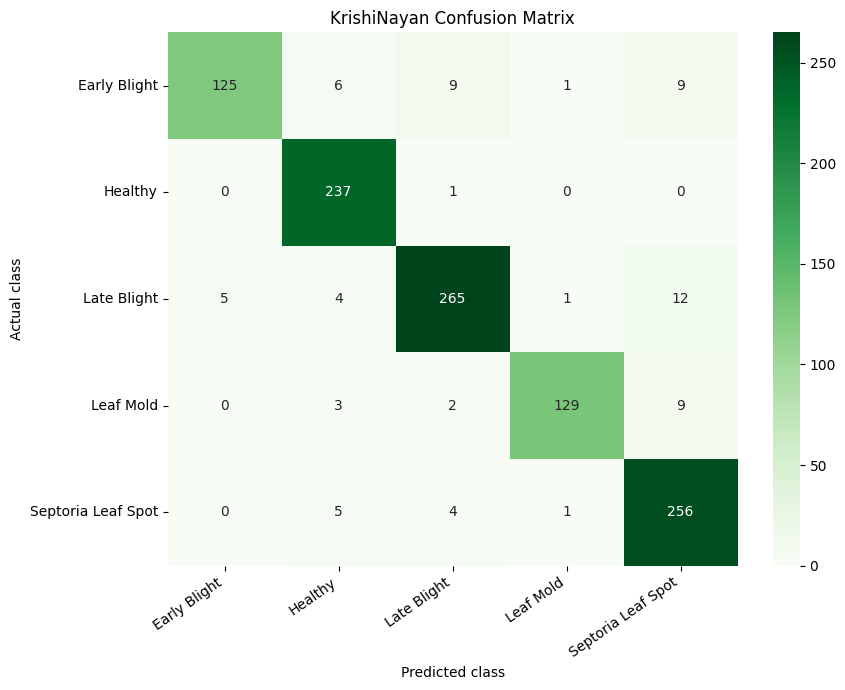

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

true_labels = np.concatenate(
    [
        labels.numpy()
        for _, labels in test_dataset
    ]
)

prediction_probabilities = model.predict(
    test_dataset
)

predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=DISPLAY_CLASS_NAMES,
        digits=4
    )
)

matrix = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=DISPLAY_CLASS_NAMES,
    yticklabels=DISPLAY_CLASS_NAMES
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("KrishiNayan Confusion Matrix")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR
    / "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

#Save model and class mapping

In [ ]:
FINAL_MODEL_PATH = (
    OUTPUT_DIR
    / "KrishiNayan_Tomato_EfficientNetB0.keras"
)

CLASS_NAMES_PATH = (
    OUTPUT_DIR
    / "class_names.json"
)

model.save(FINAL_MODEL_PATH)

class_information = {
    "image_size": list(IMAGE_SIZE),
    "folder_class_names": (
        CLASS_FOLDER_NAMES
    ),
    "display_class_names": (
        DISPLAY_CLASS_NAMES
    )
}

with open(
    CLASS_NAMES_PATH,
    "w"
) as file:
    json.dump(
        class_information,
        file,
        indent=4
    )

print("Model saved:", FINAL_MODEL_PATH)
print("Classes saved:", CLASS_NAMES_PATH)

Model saved: /content/KrishiNayan_outputs/KrishiNayan_Tomato_EfficientNetB0.keras
Classes saved: /content/KrishiNayan_outputs/class_names.json


#Download results

In [ ]:
from google.colab import files

files.download(str(FINAL_MODEL_PATH))
files.download(str(CLASS_NAMES_PATH))
files.download(str(PLOT_PATH))
files.download(str(CONFUSION_MATRIX_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_model = keras.models.load_model(
    CHECKPOINT_PATH
)

best_model.save(FINAL_MODEL_PATH)

files.download(str(FINAL_MODEL_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Evaluation + Explainability

In this section, we evaluate the trained tomato disease model using test accuracy, confusion matrix, classification report, wrong prediction analysis, and Grad-CAM heatmap.

### 3.1 Load Trained Model


### 3.2 Load Test Dataset